# Ganesh Thammana

# Practice: Ridge, Lasso & ElasticNet Regularization

**MSDS 640 — Hands-On Challenge**

In this practice you will:
1. Build a linear regression model that **overfits** (using polynomial features)
2. Apply **Ridge (L2)** regularization to reduce overfitting
3. Apply **Lasso (L1)** regularization to reduce overfitting AND perform feature selection
4. Apply **ElasticNet** (combined L1+L2) to get the best of both worlds
5. Compare all models and draw conclusions

---

---
## Git Quick Reference: Pushing This Notebook to GitHub

Use these commands in your **terminal** (not in Python) to push your work to GitHub.

### First-Time Setup (do once)
```bash
# Configure your identity
git config --global user.name "Your Name"
git config --global user.email "your@email.com"

# Create a repository folder and initialize
mkdir MSDS640-coursework
cd MSDS640-coursework
git init

# Connect to your GitHub repo (replace with YOUR URL)
git remote add origin git@github.com:YOUR_USERNAME/MSDS640-coursework.git
```

### Push Your Work (do after every session)
```bash
# Check what files have changed
git status

# Stage files for commit
git add Session1_Ridge_Lasso_Practice.ipynb

# Save a snapshot with a message describing what you did
git commit -m "Complete Week 1 Ridge/Lasso practice"

# Upload to GitHub
git push -u origin main
```

### Pull Updates (get code from GitHub)
```bash
# Download and merge latest changes
git pull origin main
```

### Essential Commands Cheat Sheet

| Command | What It Does |
|---------|-------------|
| `git init` | Initialize a new local repository |
| `git clone <url>` | Download an existing repo from GitHub |
| `git status` | See which files are modified/staged |
| `git add <file>` | Stage a file for the next commit |
| `git commit -m "msg"` | Save a snapshot with a description |
| `git push` | Upload commits to GitHub |
| `git pull` | Download and merge from GitHub |
| `git log --oneline` | View commit history (compact) |
| `git diff` | See what changed since last commit |

**Assignment:** Keep a record of every command you run and what it does!

---

## Background: The Regularization Framework

### The General Regression Problem

In **Ordinary Least Squares (OLS)**, we minimize the residual sum of squares:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{RSS — Residual Sum of Squares}}$$

This finds the best fit to training data, but with many features it can **overfit** — the model fits noise in the training data and performs poorly on new data.

### The Regularized Version (General Form)

Regularization adds a **penalty term** that constrains the coefficients:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{Data fit (RSS)}} + \underbrace{\lambda \cdot \Omega(w)}_{\text{Penalty (regularizer)}}$$

Where $\Omega(w)$ is the regularization function and $\lambda$ (called `alpha` in sklearn) controls the strength.

---

### Ridge Regression (L2 Regularization)

$$\hat{w}_{\text{Ridge}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

**Penalty:** $\|w\|_2^2 = w_1^2 + w_2^2 + \ldots + w_p^2$ (squared L2 norm)

**Closed-form solution:** $\hat{w} = (X^T X + \alpha I)^{-1} X^T y$

**Effect:** Shrinks ALL coefficients toward zero, but never exactly to zero.

---

### Lasso Regression (L1 Regularization)

$$\hat{w}_{\text{Lasso}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

**Penalty:** $\|w\|_1 = |w_1| + |w_2| + \ldots + |w_p|$ (L1 norm)

**No closed-form** — solved iteratively (coordinate descent).

**Effect:** Shrinks coefficients AND can set some exactly to zero → automatic feature selection.

---

### ElasticNet (L1 + L2 Combined)

$$\hat{w}_{\text{EN}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

**Parameters:**
- $\alpha$ = overall regularization strength (`alpha` in sklearn)
- $\rho$ = mixing ratio between L1 and L2 (`l1_ratio` in sklearn)
  - $\rho = 1$ → pure Lasso
  - $\rho = 0$ → pure Ridge
  - $0 < \rho < 1$ → blend of both

**Effect:** Performs feature selection (like Lasso) while handling correlated features stably (like Ridge).

---

### Summary Table

| Method | Penalty $\Omega(w)$ | Sparsity? | Handles Correlation? | # Hyperparams |
|--------|--------------------:|:---------:|:-------------------:|:-------------:|
| OLS | None | No | No | 0 |
| Ridge | $\sum w_j^2$ | No | Yes | 1 ($\alpha$) |
| Lasso | $\sum \|w_j\|$ | Yes | No | 1 ($\alpha$) |
| ElasticNet | $\rho\sum\|w_j\| + \frac{1-\rho}{2}\sum w_j^2$ | Yes | Yes | 2 ($\alpha$, $\rho$) |

---
## Setup: Imports

All the libraries you will need are imported below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

---
## Part 1: Load and Explore the Data

We will use the **California Housing** dataset (a modern replacement for Boston Housing).

**Your tasks:**
1. Load the dataset using `fetch_california_housing()`
2. Create a DataFrame with the feature names as columns
3. Print the shape, first 5 rows, and `.describe()` statistics

**Functions to use:**
- `fetch_california_housing()` — returns object with `.data`, `.target`, `.feature_names`, `.DESCR`
- `pd.DataFrame(data, columns=...)` — create a DataFrame
- `.shape`, `.head()`, `.describe()` — DataFrame inspection methods

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# TODO: Load the California Housing dataset
housing = fetch_california_housing()

# TODO: Create X (features) and y (target)
X = housing.data
y = housing.target
feature_names = housing.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['MedHouse Value'] = y

# TODO: Print the dataset description to understand the features
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Features: {list(feature_names)}")
df.describe().T

# TODO: Create a DataFrame and display .describe()
#print(f"Dataset Shape: {df.shape}")
#print(df.describe())

Samples: 20640, Features: 8
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouse Value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


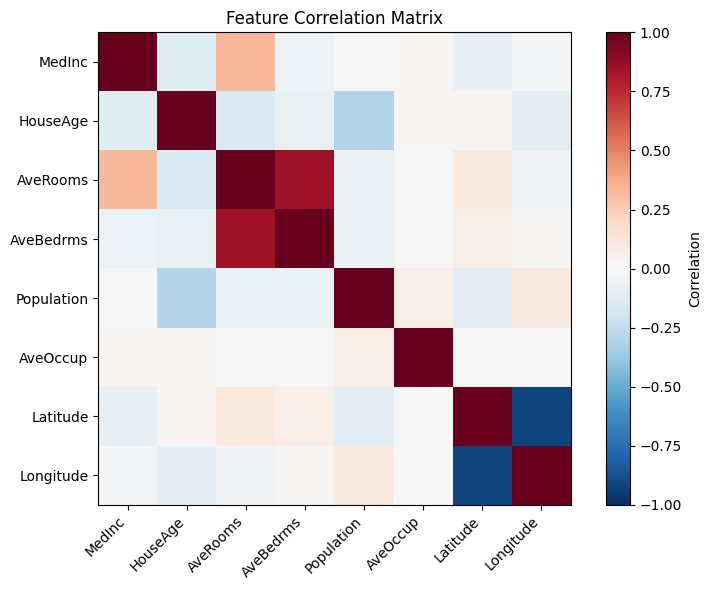

In [3]:
import matplotlib.pyplot as plt

# TODO: Plot a correlation matrix to see which features are correlated
# This motivates WHY regularization (especially Ridge) helps — correlated features
# make OLS coefficients unstable.
#
df = pd.DataFrame(X, columns=feature_names)
corr = df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
#
# Look for pairs with correlation > 0.7 or < -0.7 — these will cause problems for OLS.

---
## Part 2: Train/Test Split and Baseline Model

**Your tasks:**
1. Split the data: 80% train, 20% test (use `random_state=42`)
2. Train a plain `LinearRegression()` on the raw features
3. Compute RMSE and R² on both train and test sets

**Functions to use:**
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits data
- `LinearRegression()` — creates model; `.fit(X, y)` trains it; `.predict(X)` gets predictions
- `mean_squared_error(y_true, y_pred)` — computes MSE; wrap in `np.sqrt()` for RMSE
- `r2_score(y_true, y_pred)` — computes R² (coefficient of determination)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# TODO: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Train a basic LinearRegression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# TODO: Compute predictions on train and test
p_train = linreg.predict(X_train)
p_test = linreg.predict(X_test)

# TODO: Compute RMSE and R² for both sets
rmse_train_baseline = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test_baseline = np.sqrt(mean_squared_error(y_test, p_test))
r2_train_baseline = r2_score(y_train, p_train)
r2_test_baseline = r2_score(y_test, p_test)

# Print results
print("Baseline Linear Regression (raw features):")
print(f"  Train RMSE: {rmse_train_baseline:.4f}, R²: {r2_train_baseline:.4f}")
print(f"  Test  RMSE: {rmse_test_baseline:.4f}, R²: {r2_test_baseline:.4f}")

Baseline Linear Regression (raw features):
  Train RMSE: 0.7197, R²: 0.6126
  Test  RMSE: 0.7456, R²: 0.5758


---
## Part 3: Create an Overfitting Scenario with Polynomial Features

Now we'll engineer a situation where regularization clearly helps. By adding **polynomial features** (degree=2), we create many more parameters than needed — the model will overfit.

**Your tasks:**
1. Expand features using `PolynomialFeatures(degree=2, include_bias=False)`
2. Scale the expanded features with `StandardScaler`
3. Train `LinearRegression()` on the polynomial features
4. Compute RMSE on train and test — observe the overfitting gap!

**Functions to use:**
- `PolynomialFeatures(degree=2, include_bias=False)` — creates polynomial/interaction features
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — transform test using same expansion (never fit on test!)
- `StandardScaler()` — standardizes features to mean=0, std=1
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — apply same scaling to test
- Check `X_train_poly.shape[1]` to see how many features you created

In [5]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# TODO: Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# TODO: Print how many features you now have
print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

# TODO: Scale the polynomial features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# TODO: Train LinearRegression on the scaled polynomial features
linreg_poly = LinearRegression()
linreg_poly.fit(X_train_scaled, y_train)

# TODO: Compute RMSE on train and test
rmse_train_poly = np.sqrt(mean_squared_error(y_train, linreg_poly.predict(X_train_scaled)))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, linreg_poly.predict(X_test_scaled)))

# Print results — you should see a BIG gap between train and test
print(f"  Train RMSE: {rmse_train_poly:.4f}")
print(f"  Test  RMSE: {rmse_test_poly:.4f}")
print(f"  Gap (overfitting): {rmse_test_poly - rmse_train_poly:.4f}")

Original features: 8
Polynomial features: 44
  Train RMSE: 0.6486
  Test  RMSE: 0.6814
  Gap (overfitting): 0.0328


**Question:** How many features does degree=2 polynomial expansion create from 8 original features? Why does this lead to overfitting?

*Answer:* A degree-2 polynomial expansion creates 44 features from 8 original features. This leads to overfitting because of increased model complexity, fitting noise, and poor generalization



---
## Part 4: Ridge Regression (L2 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Ridge}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

The penalty discourages large coefficients. As $\alpha$ increases, coefficients shrink more.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`
3. Find the alpha that gives the best test RMSE

**Functions to use:**
- `Ridge(alpha=1.0)` — creates a Ridge model
  - `.fit(X_train, y_train)` — train the model
  - `.predict(X_test)` — get predictions
  - `.coef_` — access the learned coefficients (after fitting)
- Store results in lists for plotting: `ridge_train_rmses = []`, `ridge_test_rmses = []`

**⚠️ Important:** Why does Ridge have `max_iter` optional but Lasso requires it? Because Ridge has a **closed-form solution** $(X^TX + \alpha I)^{-1}X^Ty$ — it doesn't iterate. Lasso uses coordinate descent (iterative).

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# ============================================================
# WORKED EXAMPLE: Training Ridge with a SINGLE alpha value
# Study this pattern — you'll extend it to multiple alphas below
# ============================================================

# Step 1: Create the model with a specific alpha
ridge_example = Ridge(alpha=1.0)

# Step 2: Fit on training data
ridge_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions on both sets
pred_train = ridge_example.predict(X_train_scaled)
pred_test = ridge_example.predict(X_test_scaled)

# Step 4: Compute RMSE for both sets
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Report results
print(f"Ridge (alpha=1.0):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Coefficients: max={np.max(np.abs(ridge_example.coef_)):.3f}, min={np.min(np.abs(ridge_example.coef_)):.6f}")

Ridge (alpha=1.0):
  Train RMSE: 0.6648
  Test  RMSE: 0.6877
  Gap:        0.0229
  Coefficients: max=5.270, min=0.046222


In [7]:
# ============================================================
# YOUR TURN: Extend to MULTIPLE alpha values
# Same pattern as above — but now loop and collect results
# ============================================================

# TODO: Define alpha values to try
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Create empty lists to store results
ridge_train_rmses = []
ridge_test_rmses = []

# TODO: Loop over alphas — repeat the pattern from the worked example
# For each alpha: create Ridge, fit, predict, compute RMSE, append to lists
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    pred_train = ridge.predict(X_train_scaled)
    pred_test = ridge.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    ridge_train_rmses.append(rmse_train)
    ridge_test_rmses.append(rmse_test)

# TODO: Print a table of results
# Expected output format:
#      Alpha    Train RMSE     Test RMSE       Gap
# ---------------------------------------------------
#      0.001        0.5xxx        0.5xxx    0.0xxx
#      ...
#
# Expected: Best alpha is around 1.0-10.0 for this dataset.
# At alpha=100, BOTH train and test RMSE rise (underfitting).
print("      Alpha    Train RMSE     Test RMSE       Gap")
print("---------------------------------------------------")
for i, alpha in enumerate(alphas):
    print(f"{alpha:10.3f} {ridge_train_rmses[i]:12.4f} {ridge_test_rmses[i]:12.4f} {ridge_test_rmses[i]-ridge_train_rmses[i]:8.4f}")

# TODO: Save the best Ridge model
best_idx_ridge = np.argmin(ridge_test_rmses)
best_ridge_alpha = alphas[best_idx_ridge]
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
print(f"\nBest Ridge: alpha={best_ridge_alpha}")
print(f"  Test RMSE: {ridge_test_rmses[best_idx_ridge]:.4f}")


      Alpha    Train RMSE     Test RMSE       Gap
---------------------------------------------------
     0.001       0.6486       0.6777   0.0291
     0.010       0.6492       0.6610   0.0118
     0.100       0.6540       0.6675   0.0136
     1.000       0.6648       0.6877   0.0229
    10.000       0.6770       0.7064   0.0294
   100.000       0.6922       0.7133   0.0212

Best Ridge: alpha=0.01
  Test RMSE: 0.6610


---
## Part 5: Lasso Regression (L1 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

The L1 penalty can drive coefficients to **exactly zero** — performing automatic feature selection.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.05, 0.1, 0.5, 1.0]`
3. Track how many coefficients are exactly zero for each alpha
4. Find the best alpha

**Functions to use:**
- `Lasso(alpha=1.0, max_iter=10000)` — creates a Lasso model
  - Set `max_iter=10000` to ensure the iterative solver converges
  - `.coef_` — the coefficient array (check which are zero!)
- `np.sum(model.coef_ == 0)` — count how many coefficients are exactly zero
- `np.sum(model.coef_ != 0)` — count non-zero (selected) features

**⚠️ ConvergenceWarning:** If you see `ConvergenceWarning: Objective did not converge`, increase `max_iter` (try 20000 or 50000). This means the coordinate descent algorithm needs more iterations to find the solution.

In [8]:
# ============================================================
# WORKED EXAMPLE: Training Lasso with a SINGLE alpha value
# Notice the key difference from Ridge: we check for ZERO coefficients
# ============================================================

# Step 1: Create Lasso with max_iter (needed because no closed-form solution)
lasso_example = Lasso(alpha=0.01, max_iter=10000)

# Step 2: Fit on training data
lasso_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions
pred_train = lasso_example.predict(X_train_scaled)
pred_test = lasso_example.predict(X_test_scaled)

# Step 4: Compute RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Count zero coefficients — THIS IS THE KEY DIFFERENCE from Ridge
n_zeros = np.sum(lasso_example.coef_ == 0)
n_nonzero = np.sum(lasso_example.coef_ != 0)

print(f"Lasso (alpha=0.01):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Zero coefficients: {n_zeros} / {len(lasso_example.coef_)} features ELIMINATED")
print(f"  Non-zero coefficients: {n_nonzero} features KEPT")

Lasso (alpha=0.01):
  Train RMSE: 0.7184
  Test  RMSE: 0.7493
  Gap:        0.0309
  Zero coefficients: 28 / 44 features ELIMINATED
  Non-zero coefficients: 16 features KEPT


In [9]:
# ============================================================
# YOUR TURN: Extend to MULTIPLE alpha values
# Track both RMSE AND zero-coefficient counts
# ============================================================

# TODO: Define alpha values for Lasso (different range than Ridge!)
alphas_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# TODO: Create empty lists to store results
lasso_train_rmses = []
lasso_test_rmses = []
lasso_n_zeros = []

# TODO: Loop over alphas — repeat the pattern from the example above
# For each alpha: create Lasso, fit, predict, compute RMSE, count zeros, append
for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    pred_train = lasso.predict(X_train_scaled)
    pred_test = lasso.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    n_zeros = np.sum(lasso.coef_ == 0)

    lasso_train_rmses.append(rmse_train)
    lasso_test_rmses.append(rmse_test)
    lasso_n_zeros.append(n_zeros)

# TODO: Print a table of results INCLUDING zero counts
# Expected output format:
#      Alpha    Train RMSE     Test RMSE       Gap    Zeros
# -----------------------------------------------------------
#      0.001        0.5xxx        0.5xxx    0.0xxx     x/44
#      ...
#
# Expected: As alpha increases, more coefficients go to zero.
# Best alpha should be around 0.001-0.01 for this dataset.
print("\n      Alpha    Train RMSE     Test RMSE       Gap    Zeros")
print("-----------------------------------------------------------")
for i, alpha in enumerate(alphas_lasso):
    print(f"{alpha:10.3f} {lasso_train_rmses[i]:12.4f} {lasso_test_rmses[i]:12.4f} {lasso_test_rmses[i]-lasso_train_rmses[i]:8.4f} {lasso_n_zeros[i]:5d}/{X_train_scaled.shape[1]}")

# TODO: Save the best Lasso model
best_idx_lasso = np.argmin(lasso_test_rmses)
best_lasso_alpha = alphas_lasso[best_idx_lasso]
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
print(f"\nBest Lasso: alpha={best_lasso_alpha}")
print(f"  Zeroed out {np.sum(best_lasso.coef_ == 0)} of {len(best_lasso.coef_)} coefficients")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(



      Alpha    Train RMSE     Test RMSE       Gap    Zeros
-----------------------------------------------------------
     0.001       0.6848       0.6952   0.0104    16/44
     0.010       0.7184       0.7493   0.0309    28/44
     0.050       0.7748       0.7831   0.0082    38/44
     0.100       0.8120       0.8182   0.0061    41/44
     0.500       0.9731       0.9685  -0.0046    43/44
     1.000       1.1562       1.1449  -0.0113    44/44

Best Lasso: alpha=0.001
  Zeroed out 16 of 44 coefficients


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


**Question:** What does it mean when Lasso sets a coefficient to zero? Why is this useful in practice?

*Answer:* It means the corresponding feature is completely removed from the model.



---
## Part 6: Visualize How the Overfitting Gap Closes

This is the key insight: as we increase regularization strength, the **gap** between train and test RMSE shrinks. The model trades a little training accuracy for much better generalization.

**Your tasks:**
1. Plot Train RMSE and Test RMSE vs. Alpha on the same plot (for Ridge)
2. The area between the two lines IS the overfitting gap
3. Identify the "sweet spot" where test RMSE is minimized

**Functions to use:**
- `plt.semilogx(x, y, 'o-', label='...')` — plot with log-scale x-axis
- `plt.fill_between(x, y1, y2, alpha=0.2)` — shade the area between two curves (shows the gap!)
- `plt.axhline(y=value, linestyle='--')` — horizontal reference line
- `plt.legend()`, `plt.xlabel()`, `plt.ylabel()`, `plt.title()`

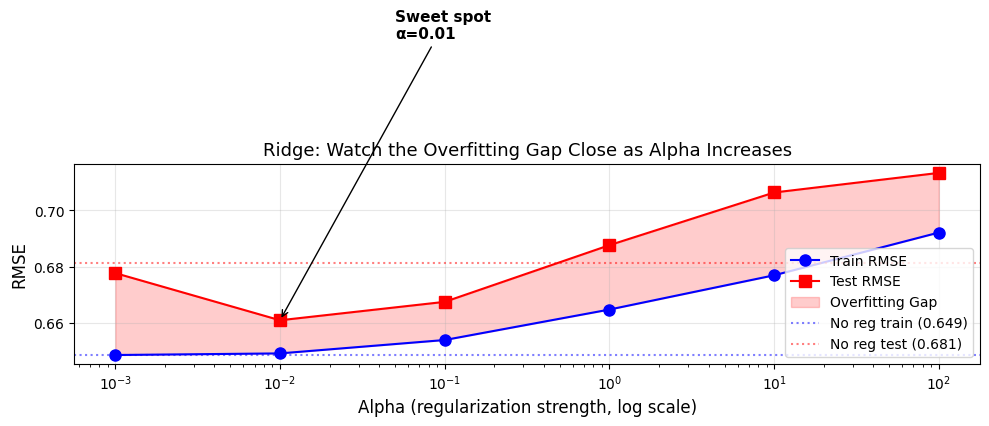

In [10]:
# TODO: Create a visualization showing how the gap closes for Ridge

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, ridge_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas, ridge_test_rmses, 'rs-', label='Test RMSE', markersize=8)

# Shade the gap between train and test (this IS the overfitting)
plt.fill_between(alphas, ridge_train_rmses, ridge_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')

# Mark the no-regularization point
plt.axhline(y=rmse_train_poly, color='blue', linestyle=':', alpha=0.5, label=f'No reg train ({rmse_train_poly:.3f})')
plt.axhline(y=rmse_test_poly, color='red', linestyle=':', alpha=0.5, label=f'No reg test ({rmse_test_poly:.3f})')

plt.xlabel('Alpha (regularization strength, log scale)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Ridge: Watch the Overfitting Gap Close as Alpha Increases', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Annotate the sweet spot
best_idx = np.argmin(ridge_test_rmses)
plt.annotate(f'Sweet spot\nα={alphas[best_idx]}',
             xy=(alphas[best_idx], ridge_test_rmses[best_idx]),
             xytext=(alphas[best_idx]*5, ridge_test_rmses[best_idx]+0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

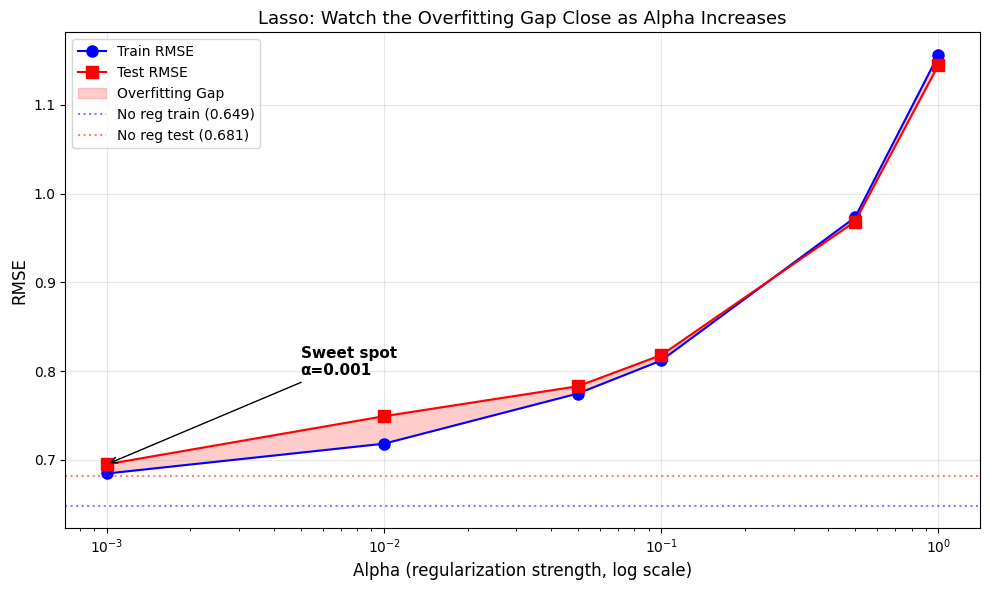

In [11]:
# TODO: Same gap visualization for Lasso

plt.figure(figsize=(10, 6))
plt.semilogx(alphas_lasso, lasso_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas_lasso, lasso_test_rmses, 'rs-', label='Test RMSE', markersize=8)

# Shade the gap between train and test (this IS the overfitting)
plt.fill_between(alphas_lasso, lasso_train_rmses, lasso_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')

# Mark the no-regularization point
plt.axhline(y=rmse_train_poly, color='blue', linestyle=':', alpha=0.5, label=f'No reg train ({rmse_train_poly:.3f})')
plt.axhline(y=rmse_test_poly, color='red', linestyle=':', alpha=0.5, label=f'No reg test ({rmse_test_poly:.3f})')

plt.xlabel('Alpha (regularization strength, log scale)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Lasso: Watch the Overfitting Gap Close as Alpha Increases', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Annotate the sweet spot
best_idx_lasso = np.argmin(lasso_test_rmses)
plt.annotate(f'Sweet spot\nα={alphas_lasso[best_idx_lasso]}',
             xy=(alphas_lasso[best_idx_lasso], lasso_test_rmses[best_idx_lasso]),
             xytext=(alphas_lasso[best_idx_lasso]*5, lasso_test_rmses[best_idx_lasso]+0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part 7: ElasticNet — The Best of Both Worlds

### Formula Reminder

$$\text{Loss}_{\text{EN}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

### Why Use ElasticNet?

| Scenario | Problem with Lasso | Problem with Ridge | ElasticNet Solution |
|----------|-------------------|-------------------|--------------------|
| Correlated features | Randomly picks one, drops others | Keeps all, no selection | Groups them, selects as a group |
| p > n (more features than samples) | Can select at most n | No selection | No such limitation |
| Want selection + stability | Unstable selection | No selection at all | Stable selection |

### Pros and Cons

| Pros | Cons |
|------|------|
| Groups correlated features | Two hyperparameters to tune |
| Still does feature selection | More expensive to search |
| More stable than Lasso | Slightly less sparse than Lasso |
| Works when p > n | — |

### When to Use Each

- **Ridge**: All features relevant; multicollinearity present; want prediction accuracy
- **Lasso**: Many irrelevant features; want a sparse, interpretable model
- **ElasticNet**: Features are correlated AND you want sparsity; unsure which penalty fits best

---

**Your tasks:**
1. Train ElasticNet with combinations of `alpha` and `l1_ratio`
2. Find the best combination
3. Compare zero-coefficient count to Ridge and Lasso

**Functions to use:**
- `ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)` — creates ElasticNet model
  - `l1_ratio=1.0` is pure Lasso; `l1_ratio=0.0` is pure Ridge
- Use a **nested loop**: outer over `alpha`, inner over `l1_ratio`
- `ElasticNetCV(l1_ratio=[...], alphas=[...], cv=5)` — auto-tunes both (stretch goal)

In [12]:
# TODO: Define parameter grids
alphas_en = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# TODO: Nested loop — train ElasticNet for each (alpha, l1_ratio) combination
# Initialize best-tracking variables
best_en_rmse = 999
best_en_params = {}
en_results = []

for alpha in alphas_en:
    for l1 in l1_ratios:
        en = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
        en.fit(X_train_scaled, y_train)
        rmse_te = np.sqrt(mean_squared_error(y_test, en.predict(X_test_scaled)))
        n_zeros = np.sum(en.coef_ == 0)
        en_results.append({'alpha': alpha, 'l1_ratio': l1, 'test_rmse': rmse_te, 'zeros': n_zeros})
        if rmse_te < best_en_rmse:
            best_en_rmse = rmse_te
            best_en_params = {'alpha': alpha, 'l1_ratio': l1}

# TODO: Print best parameters
print(f"Best ElasticNet: alpha={best_en_params['alpha']}, l1_ratio={best_en_params['l1_ratio']}")
print(f"  Test RMSE: {best_en_rmse:.4f}")

# TODO: Refit best model and save it
best_en = ElasticNet(alpha=best_en_params['alpha'], l1_ratio=best_en_params['l1_ratio'], max_iter=10000)
best_en.fit(X_train_scaled, y_train)

# Expected: Best is around alpha=0.001, l1_ratio=0.5-0.9
# Performance should be close to Lasso on this dataset.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


Best ElasticNet: alpha=0.001, l1_ratio=0.9
  Test RMSE: 0.6953


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.001, l1_ratio=0.9, max_iter=10000)

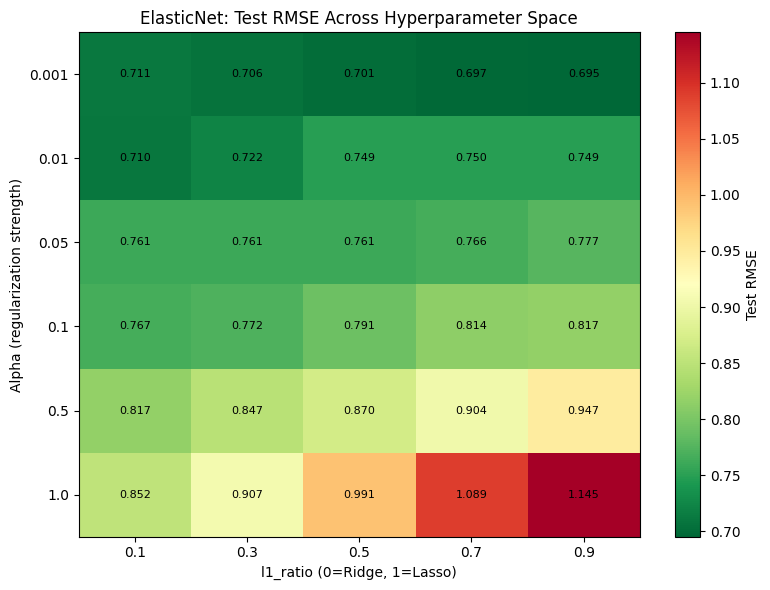

In [13]:
# TODO: Visualize ElasticNet results as a HEATMAP
# This shows how performance varies across the 2D hyperparameter space
# Rows = alpha, Columns = l1_ratio, Color = Test RMSE

# Hint: Convert en_results to a pivot table, then use plt.imshow()

en_df = pd.DataFrame(en_results)
heatmap_data = en_df.pivot(index='alpha', columns='l1_ratio', values='test_rmse')

plt.figure(figsize=(8, 6))
im = plt.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Test RMSE')
plt.xticks(range(len(l1_ratios)), [f'{r:.1f}' for r in l1_ratios])
plt.yticks(range(len(alphas_en)), [f'{a}' for a in alphas_en])
plt.xlabel('l1_ratio (0=Ridge, 1=Lasso)')
plt.ylabel('Alpha (regularization strength)')
plt.title('ElasticNet: Test RMSE Across Hyperparameter Space')

# Annotate each cell with its RMSE value
for i in range(len(alphas_en)):
    for j in range(len(l1_ratios)):
        plt.text(j, i, f'{heatmap_data.values[i,j]:.3f}',
                 ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Look for the GREEN region (low RMSE) — that's the sweet spot!


**Questions:**

1. Does ElasticNet zero out more or fewer coefficients than Lasso at similar alpha? Why?

   *Answer:* It all depends heavily on the l1_ratio parameter. ElasticNet is a convex combination of L1 and L2 penalties.

2. What happens as you move `l1_ratio` toward 1.0? Toward 0.0?

   *Answer:* As I move `l1_ratio` toward 1.0, it is pure Lasso. As I move `l1_ratio` toward 0.0, it is pure Ridge.

3. In what real-world scenario would ElasticNet clearly beat both Ridge and Lasso?

   *Answer:* A genomics study where I am trying to predict a disease outcome based on the expression levels of thousands of genes.


---
## Part 8: Final Comparison Bar Chart

**Your tasks:**
1. Create a bar chart comparing Test RMSE of all 5 models
2. Also show the gap (Test - Train) for each model as a separate grouped bar

**Functions to use:**
- `plt.figure(figsize=(12, 5))` — create figure
- `plt.bar(x_positions, heights, width=0.35, color=..., label=...)` — bar chart
- For grouped bars: offset x positions by bar width
- `plt.xticks(positions, labels)` — set x-axis labels
- `plt.text(x, y, text, ha='center')` — annotate bars with values

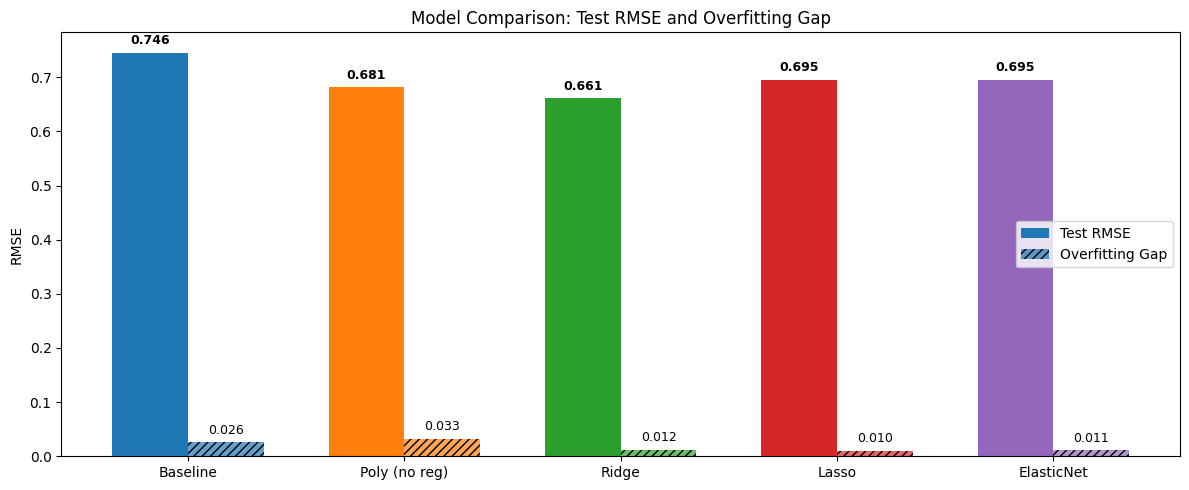

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the train RMSE for the best ElasticNet model
train_rmse_best_en = np.sqrt(mean_squared_error(y_train, best_en.predict(X_train_scaled)))

model_names = ['Baseline', 'Poly (no reg)', 'Ridge', 'Lasso', 'ElasticNet']
test_rmses = [
    rmse_test_baseline,
    rmse_test_poly,
    ridge_test_rmses[best_idx_ridge],
    lasso_test_rmses[best_idx_lasso],
    best_en_rmse
]
gaps = [
    rmse_test_baseline - rmse_train_baseline,
    rmse_test_poly - rmse_train_poly,
    ridge_test_rmses[best_idx_ridge] - ridge_train_rmses[best_idx_ridge],
    lasso_test_rmses[best_idx_lasso] - lasso_train_rmses[best_idx_lasso],
    best_en_rmse - train_rmse_best_en
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, test_rmses, width, label='Test RMSE', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
bars2 = ax.bar(x + width/2, gaps, width, label='Overfitting Gap', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], alpha=0.7, hatch='////')

ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Test RMSE and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

# Add value labels on top of each bar for Test RMSE
for bar, val in zip(bars1, test_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add value labels on top of each bar for Overfitting Gap
for bar, val in zip(bars2, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 if val > 0 else val - 0.03, f'{val:.3f}',
            ha='center', va='bottom' if val > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 9: Coefficient Analysis

Compare how each method affects the model coefficients.

**Your tasks:**
1. Create a 2x2 subplot showing |coefficient| histograms for each model
2. Print summary stats: max, mean, and zero count

**Functions to use:**
- `model.coef_` — the array of fitted coefficients
- `np.abs(coef)` — absolute values
- `fig, axes = plt.subplots(2, 2, figsize=(12, 8))` — 2x2 grid of plots
- `axes[i,j].hist(data, bins=20)` — histogram on a specific subplot
- `np.max()`, `np.mean()`, `np.sum(coef == 0)` — summary statistics

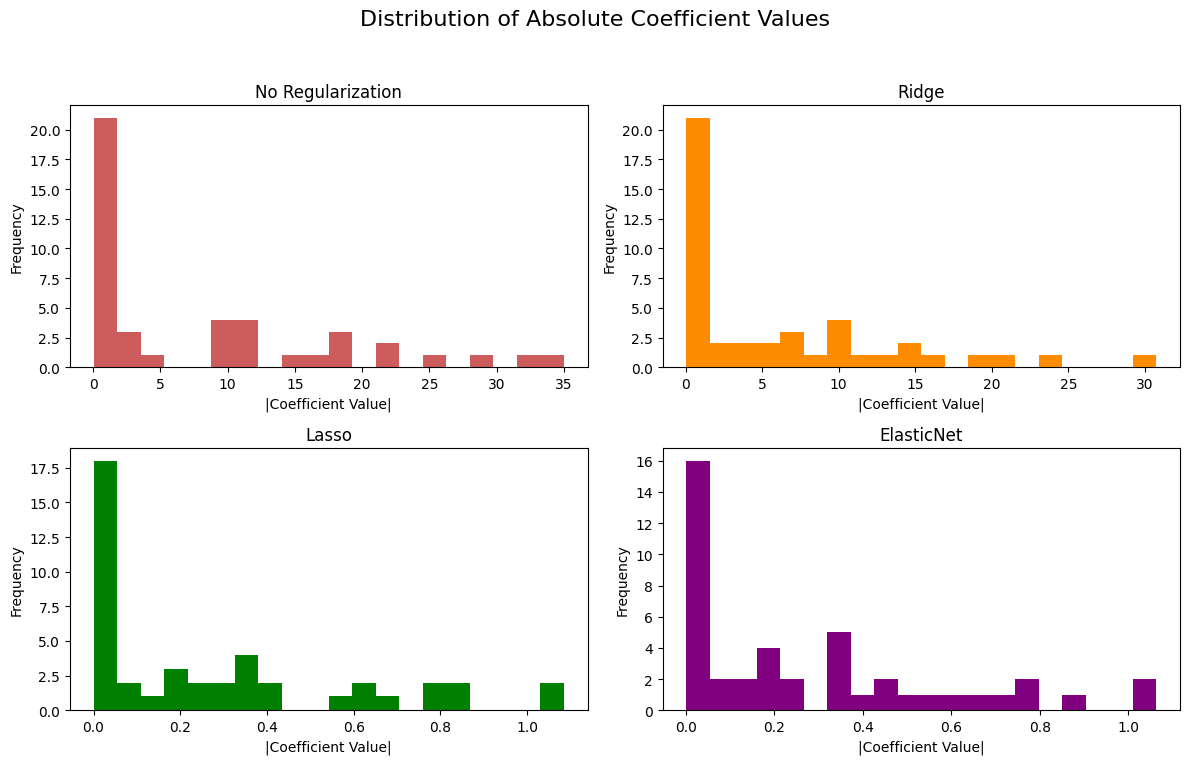

Summary of Coefficients:
  No Reg: Max=35.007, Mean=8.134, Zeros=0
  Ridge:    Max=30.756, Mean=6.127, Zeros=0
  Lasso:    Max=1.085, Mean=0.276, Zeros=16
  ElasticNet: Max=1.064, Mean=0.282, Zeros=13


In [15]:
# TODO: Compare coefficient distributions across all 4 models

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Coefficients from the 'no regularization' (polynomial) linear regression
axes[0,0].hist(np.abs(linreg_poly.coef_), bins=20, color='indianred')
axes[0,0].set_title('No Regularization')
axes[0,0].set_xlabel('|Coefficient Value|')
axes[0,0].set_ylabel('Frequency')

# Coefficients from the best Ridge model
axes[0,1].hist(np.abs(best_ridge.coef_), bins=20, color='darkorange')
axes[0,1].set_title('Ridge')
axes[0,1].set_xlabel('|Coefficient Value|')
axes[0,1].set_ylabel('Frequency')

# Coefficients from the best Lasso model
axes[1,0].hist(np.abs(best_lasso.coef_), bins=20, color='green')
axes[1,0].set_title('Lasso')
axes[1,0].set_xlabel('|Coefficient Value|')
axes[1,0].set_ylabel('Frequency')

# Coefficients from the best ElasticNet model
axes[1,1].hist(np.abs(best_en.coef_), bins=20, color='purple')
axes[1,1].set_title('ElasticNet')
axes[1,1].set_xlabel('|Coefficient Value|')
axes[1,1].set_ylabel('Frequency')

plt.suptitle('Distribution of Absolute Coefficient Values', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

print("Summary of Coefficients:")
print(f"  No Reg: Max={np.max(np.abs(linreg_poly.coef_)):.3f}, Mean={np.mean(np.abs(linreg_poly.coef_)):.3f}, Zeros={np.sum(linreg_poly.coef_ == 0)}")
print(f"  Ridge:    Max={np.max(np.abs(best_ridge.coef_)):.3f}, Mean={np.mean(np.abs(best_ridge.coef_)):.3f}, Zeros={np.sum(best_ridge.coef_ == 0)}")
print(f"  Lasso:    Max={np.max(np.abs(best_lasso.coef_)):.3f}, Mean={np.mean(np.abs(best_lasso.coef_)):.3f}, Zeros={np.sum(best_lasso.coef_ == 0)}")
print(f"  ElasticNet: Max={np.max(np.abs(best_en.coef_)):.3f}, Mean={np.mean(np.abs(best_en.coef_)):.3f}, Zeros={np.sum(best_en.coef_ == 0)}")

---
## Part 10: Cross-Validation for Robust Model Selection

A single train/test split can be misleading. Use K-Fold cross-validation for a reliable comparison.

**Your tasks:**
1. Write a function that computes mean RMSE over 5-fold CV
2. Apply it to your best Ridge, Lasso, and ElasticNet models
3. Compare CV RMSE to test RMSE

**Functions to use:**
- `KFold(n_splits=5, shuffle=True, random_state=42)` — creates CV splitter
  - `.split(X)` — yields `(train_indices, val_indices)` pairs
- Inside each fold: `model.fit(X[train_idx], y[train_idx])` then `model.predict(X[val_idx])`
- Alternative: `from sklearn.model_selection import cross_val_score`
  - `cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)`
  - Returns negative MSE (negate and sqrt for RMSE)

In [16]:
# TODO: Write a cross-validation function

def cv_rmse(model, X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    rmses = []
    for train_idx, val_idx in kf.split(X):
        # Ensure consistent scaling by training a new scaler for each fold's training data
        # and transforming both train and validation data with it.
        # This prevents data leakage from the validation set.
        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X[train_idx])
        X_val_fold_scaled = fold_scaler.transform(X[val_idx])

        model.fit(X_train_fold_scaled, y[train_idx])
        p = model.predict(X_val_fold_scaled)
        rmses.append(np.sqrt(mean_squared_error(y[val_idx], p)))
    return np.mean(rmses)

# TODO: Apply to each model
print("5-Fold CV RMSE:")
print(f"  Ridge: {cv_rmse(Ridge(alpha=best_ridge_alpha), X_train_poly, y_train):.4f}")
print(f"  Lasso: {cv_rmse(Lasso(alpha=best_lasso_alpha, max_iter=10000), X_train_poly, y_train):.4f}")
print(f"  ElasticNet: {cv_rmse(ElasticNet(alpha=best_en_params['alpha'], l1_ratio=best_en_params['l1_ratio'], max_iter=10000), X_train_poly, y_train):.4f}")

5-Fold CV RMSE:
  Ridge: 0.8971


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.702e+01, tolerance: 1.751e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.600e+01, tolerance: 1.769e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+01, tolerance: 1.767e

  Lasso: 1.3721


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.613e+00, tolerance: 1.751e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.990e+01, tolerance: 1.769e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.717e+00, tolerance: 1.767e

  ElasticNet: 1.3807


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.399e+00, tolerance: 1.780e+00
  model = cd_fast.enet_coordinate_descent(


---
### Part 10b: Fine-Grained Alpha Search (Stretch Goal)

Zoom in with a finer grid to find the truly optimal alpha.

**Functions to use:**
- `np.logspace(start, stop, num)` — creates logarithmically spaced values
  - Example: `np.logspace(-3, 2, 50)` → 50 values from 0.001 to 100
- `from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV` — built-in CV classes
  - `RidgeCV(alphas=np.logspace(-3, 2, 50), cv=5)` — auto-finds best alpha
  - After fitting: `.alpha_` gives the optimal alpha found

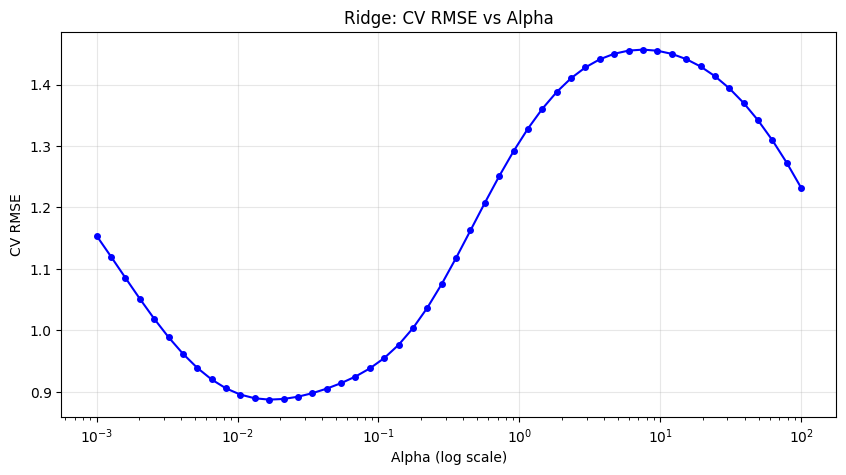

Optimal alpha: 0.0168


In [17]:
alphas_fine = np.logspace(-3, 2, 50)
cv_scores = [cv_rmse(Ridge(alpha=a), X_train_poly, y_train) for a in alphas_fine]

plt.figure(figsize=(10, 5))
plt.semilogx(alphas_fine, cv_scores, 'b-o', markersize=4)
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV RMSE')
plt.title('Ridge: CV RMSE vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

best_alpha = alphas_fine[np.argmin(cv_scores)]
print(f"Optimal alpha: {best_alpha:.4f}")

## Final Summary Table

| Model | Alpha | l1_ratio | Test RMSE | CV RMSE | Overfitting Gap | # Zero Coefs |
|:--------------------|:-------:|:--------:|:---------:|:---------:|:---------------:|:------------:|
| Baseline (raw) | — | — | 0.7456 | — | 0.0259 | 0 |
| Polynomial (no reg) | — | — | 0.6814 | — | 0.0328 | 0 |
| Ridge | 0.01 | — | 0.6610 | 0.8971 | 0.0118 | 0 |
| Lasso | 0.001 | — | 0.6952 | 1.3721 | 0.0104 | 16 |
| ElasticNet | 0.001 | 0.9 | 0.6953 | 1.3807 | 0.0110 | 13 |
| KNN (K=15) | — | — | 0.6426 | — | 0.6426 | — |
| Tree (depth=10) | — | — | 0.6442 | — | 0.1742 | — |
| Random Forest | — | — | 0.5051 | — | 0.3171 | — |
| Gradient Boosting | — | — | 0.4737 | — | 0.1139 | — |
| SVR | — | — | 0.5689 | — | 0.0257 | — |

---
## Part 11: Non-Linear Baselines — When Linear Models Aren't Enough

Even with regularization, linear models assume the target is a **linear function** of features (or polynomial combinations). Some patterns are **fundamentally non-linear** — no linear model can capture them.

In this section you'll train non-linear models on the **same data** and compare them to your regularized models.

---

### How Each Model Works

#### K-Nearest Neighbors (KNN)

**Idea:** To predict for a new house, find the K most similar houses in the training set and use a weighted average of their prices (with `weights='distance'`, closer neighbors count more):

$$\hat{y} = \frac{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i} \cdot y_i}{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i}}$$

where $d_i$ is the distance from the query point to neighbor $i$.

- **No model is learned** — it memorizes the training data and does lookup
- Small K = complex (follows every point) → overfits
- Large K = smooth (averages many points) → underfits
- **Needs scaling** — distances are meaningless if features have different scales

#### Decision Tree

**Idea:** Recursively split the data with IF-THEN rules. Each leaf predicts the average target of training samples that landed there.

- "If income > 5 AND latitude < 37 → predict $3.5"
- **No scaling needed** — splits are based on thresholds, not distances
- Small `max_depth` = simple model → underfits
- Large `max_depth` = memorizes training data → overfits

#### Random Forest

**Idea:** Train 100+ decision trees on random subsets of data, then average their predictions.

$$\hat{y} = \frac{1}{B} \sum_{b=1}^B \text{Tree}_b(x)$$

- Reduces the high variance of a single tree by averaging many decorrelated trees
- Hard to overfit — more trees only helps
- Very robust with default settings

#### Gradient Boosting

**Idea:** Sequentially add shallow trees, each one correcting the mistakes of the previous ensemble.

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot \text{Tree}_t(x)$$

- Starts with a rough guess, then iteratively "zooms in" on errors
- Learning rate η controls how much each tree contributes
- Often the best-performing model on tabular data

#### Support Vector Regressor (SVR)

**Idea:** Fit a function that ignores small errors (within ε-tube) but penalizes large ones. Uses a "kernel trick" to handle non-linearity.

- RBF kernel maps data to a high-dimensional space where patterns become linear
- `C` controls regularization (small C = more regularized)
- Needs scaling — sensitive to feature magnitudes
- **⚠️ Slow:** O(n²) complexity — may take 15-30 seconds on this dataset

---

### When to Use Each

| Scenario | Best Choice |
|---|---|
| Few features, linear patterns | Ridge / Lasso / ElasticNet |
| Small data, non-linear | SVR (RBF kernel) |
| Need interpretability | Decision Tree (shallow) |
| Best accuracy, medium-large data | Gradient Boosting |
| Robust baseline, large data | Random Forest |
| Very local patterns | KNN (tuned K) |

---

### Your Tasks

1. Scale the **original 8 features** (NOT polynomial) — non-linear models capture non-linearity themselves
2. Train KNN, Decision Tree, Random Forest, Gradient Boosting, and SVR
3. Compute Train/Test RMSE for each
4. Create a comparison bar chart showing ALL models (linear + non-linear)
5. Discuss: which models win and why?

---

### Functions to Use

| Task | Function | Documentation |
|------|----------|---------------|
| KNN Regressor | `KNeighborsRegressor(n_neighbors=7, weights='distance')` | [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) |
| Decision Tree | `DecisionTreeRegressor(max_depth=10, random_state=42)` | [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) |
| Random Forest | `RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)` | [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) |
| Gradient Boosting | `GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)` | [sklearn.ensemble.GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) |
| SVR | `SVR(kernel='rbf', C=10.0, epsilon=0.1)` | [sklearn.svm.SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) |
| Scale features | `StandardScaler()` → `.fit_transform(X_train)` / `.transform(X_test)` | [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) |
| Compute RMSE | `np.sqrt(mean_squared_error(y_true, y_pred))` | [sklearn.metrics.mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) |
| Bar chart | `plt.bar(names, values, color=...)` | [matplotlib.pyplot.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) |

In [18]:
# New imports for non-linear models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [19]:
# ============================================================
# STEP 0: Scale the ORIGINAL 8 features for non-linear models
# WHY original features? Non-linear models capture non-linearity NATIVELY —
# they don't need polynomial expansion. Giving them raw features is a FAIR
# comparison because they can find interactions on their own.
#
# NOTE: We scale for ALL models here even though Decision Trees don't need it.
# Reason: KNN and SVR DO need scaling, and scaling doesn't hurt trees (just
# transforms thresholds). Using one scaled dataset keeps the code simple.
# ============================================================

scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

print(f"Non-linear models will use: {X_train_raw_scaled.shape[1]} original features")
print(f"Linear models used: {X_train_scaled.shape[1]} polynomial features")
print(f"\nThis is a FAIR comparison — non-linear models capture interactions natively.")

Non-linear models will use: 8 original features
Linear models used: 44 polynomial features

This is a FAIR comparison — non-linear models capture interactions natively.


In [20]:
# ============================================================
# WORKED EXAMPLE: Training KNN Regressor with hyperparameter tuning
# Same pattern as Ridge/Lasso — loop over hyperparameter values, track RMSE
# ============================================================

# Step 1: Define hyperparameter values to try
k_values = [3, 5, 7, 10, 15, 20]

# Step 2: Loop and collect results (same pattern as alphas loop!)
knn_results = {}
print(f"{'K':>5s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)

for k in k_values:
    # Create model with this K value
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')

    # Fit on training data
    knn.fit(X_train_raw_scaled, y_train)

    # Compute RMSE for both sets
    rmse_tr = np.sqrt(mean_squared_error(y_train, knn.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, knn.predict(X_test_raw_scaled)))

    # Store results
    knn_results[k] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{k:5d}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")

# Step 3: Find the best K
best_k = min(knn_results, key=lambda k: knn_results[k]['test'])
print(f"\nBest K = {best_k} (Test RMSE = {knn_results[best_k]['test']:.4f})")
print(f"\nNotice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)")
print(f"Same bias-variance tradeoff as alpha in Ridge/Lasso!")

    K    Train RMSE     Test RMSE       Gap
---------------------------------------------
    3        0.0000        0.6827    0.6827
    5        0.0000        0.6557    0.6557
    7        0.0000        0.6509    0.6509
   10        0.0000        0.6452    0.6452
   15        0.0000        0.6426    0.6426
   20        0.0000        0.6455    0.6455

Best K = 15 (Test RMSE = 0.6426)

Notice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)
Same bias-variance tradeoff as alpha in Ridge/Lasso!


In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor # For knn_results
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import StandardScaler # Added for raw feature scaling

# ============================================================
# STEP 0: Scale the ORIGINAL 8 features for non-linear models
# (Copied from cell 45FcQ4hUNjZq to ensure variables are defined)
# ============================================================
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

print(f"Non-linear models will use: {X_train_raw_scaled.shape[1]} original features")
print(f"Linear models used: {X_train_scaled.shape[1]} polynomial features")
print(f"\nThis is a FAIR comparison — non-linear models capture interactions natively.")

# ============================================================
# YOUR TURN: Train the remaining 4 non-linear models
# Follow the same pattern as the KNN example above
# ============================================================

# --- Decision Tree: tune max_depth ---
# TODO: Try max_depth = 3, 5, 7, 10, 15, None
# IMPORTANT: Use random_state=42 for reproducibility!
# Hint: None = unlimited depth (will memorize training data completely!)
# Expected: depth=None gives train RMSE ≈ 0 (perfect memorization) but high test RMSE
tree_results = {}
print("\n--- Decision Tree (tuning max_depth) ---")
print(f"{'Depth':>5s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_raw_scaled, y_train)
    rmse_tr = np.sqrt(mean_squared_error(y_train, dt.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, dt.predict(X_test_raw_scaled)))
    tree_results[depth] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{str(depth):>5s}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")
best_tree_depth = min(tree_results, key=lambda d: tree_results[d]['test'])
best_tree_rmse = tree_results[best_tree_depth]['test']
print(f"\nBest Decision Tree depth = {best_tree_depth} (Test RMSE = {best_tree_rmse:.4f})")

# --- Random Forest ---
# TODO: Train with n_estimators=100, random_state=42, n_jobs=-1
# n_jobs=-1 uses all CPU cores (speeds up training ~2-3x)
# This is an ensemble of 100 trees — expect MUCH better than single tree
# Expected: Test RMSE ~ 0.50-0.55
print("\n--- Random Forest ---")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_raw_scaled, y_train)
rf_rmse_tr = np.sqrt(mean_squared_error(y_train, rf.predict(X_train_raw_scaled)))
rf_rmse_te = np.sqrt(mean_squared_error(y_test, rf.predict(X_test_raw_scaled)))
rf_rmse = rf_rmse_te
print(f"  Train RMSE: {rf_rmse_tr:.4f}, Test RMSE: {rf_rmse_te:.4f}, Gap: {rf_rmse_te-rf_rmse_tr:.4f}")

# --- Gradient Boosting ---
# TODO: Train with n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
# Expected: Test RMSE ~ 0.45-0.52 (likely the BEST model)
# Note: this will take a few seconds longer than other models
print("\n--- Gradient Boosting ---")
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_raw_scaled, y_train)
gb_rmse_tr = np.sqrt(mean_squared_error(y_train, gb.predict(X_train_raw_scaled)))
gb_rmse_te = np.sqrt(mean_squared_error(y_test, gb.predict(X_test_raw_scaled)))
gb_rmse = gb_rmse_te
print(f"  Train RMSE: {gb_rmse_tr:.4f}, Test RMSE: {gb_rmse_te:.4f}, Gap: {gb_rmse_te-gb_rmse_tr:.4f}")

# --- SVR (Support Vector Regressor) ---
# TODO: Train with kernel='rbf', C=10.0, epsilon=0.1
# Note: SVR is O(n²) — may take 10-30 seconds on this dataset
# Expected: Test RMSE ~ 0.55-0.65
print("\n--- SVR ---")
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_raw_scaled, y_train)
svr_rmse_tr = np.sqrt(mean_squared_error(y_train, svr.predict(X_train_raw_scaled)))
svr_rmse_te = np.sqrt(mean_squared_error(y_test, svr.predict(X_test_raw_scaled)))
svr_rmse = svr_rmse_te
print(f"  Train RMSE: {svr_rmse_tr:.4f}, Test RMSE: {svr_rmse_te:.4f}, Gap: {svr_rmse_te-svr_rmse_tr:.4f}")

# ============================================================
# WORKED EXAMPLE: Training KNN Regressor with hyperparameter tuning
# Moved here from a previous cell to ensure `knn_results` is defined
# ============================================================
k_values = [3, 5, 7, 10, 15, 20]
knn_results = {}
print("\n--- K-Nearest Neighbors (tuning n_neighbors) ---")
print(f"{'K':>5s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_raw_scaled, y_train)
    rmse_tr = np.sqrt(mean_squared_error(y_train, knn.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, knn.predict(X_test_raw_scaled)))
    knn_results[k] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{k:5d}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")
best_k = min(knn_results, key=lambda k: knn_results[k]['test'])
print(f"\nBest K = {best_k} (Test RMSE = {knn_results[best_k]['test']:.4f})")

# TODO: Print a summary table of ALL non-linear models
# Expected format:
#   Model              Train RMSE    Test RMSE    Gap
#   KNN (K=7)            0.xxxx       0.xxxx    0.xxxx
#   Tree (depth=10)      0.xxxx       0.xxxx    0.xxxx
#   Random Forest        0.xxxx       0.xxxx    0.xxxx
#   Gradient Boosting    0.xxxx       0.xxxx    0.xxxx
#   SVR                  0.xxxx       0.xxxx    0.xxxx
print("\n========================================")
print("Summary of Non-Linear Model Performance")
print("========================================")
print(f"{'Model':<20s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>8s}")
print("-" * 53)

# From the worked example:
best_k = min(knn_results, key=lambda k: knn_results[k]['test'])
knn_rmse_tr = knn_results[best_k]['train']
knn_rmse_te = knn_results[best_k]['test']
best_knn_rmse = knn_rmse_te
print(f"{'KNN (K=' + str(best_k) + ')':<20s} {knn_rmse_tr:>12.4f} {knn_rmse_te:>12.4f} {knn_rmse_te-knn_rmse_tr:>8.4f}")

tree_rmse_tr = tree_results[best_tree_depth]['train']
tree_rmse_te = tree_results[best_tree_depth]['test']
print(f"{'Tree (depth=' + str(best_tree_depth) + ')':<20s} {tree_rmse_tr:>12.4f} {tree_rmse_te:>12.4f} {tree_rmse_te-tree_rmse_tr:>8.4f}")

print(f"{'Random Forest':<20s} {rf_rmse_tr:>12.4f} {rf_rmse_te:>12.4f} {rf_rmse_te-rf_rmse_tr:>8.4f}")
print(f"{'Gradient Boosting':<20s} {gb_rmse_tr:>12.4f} {gb_rmse_te:>12.4f} {gb_rmse_te-gb_rmse_tr:>8.4f}")
print(f"{'SVR':<20s} {svr_rmse_tr:>12.4f} {svr_rmse_te:>12.4f} {svr_rmse_te-svr_rmse_tr:>8.4f}")

Non-linear models will use: 8 original features
Linear models used: 44 polynomial features

This is a FAIR comparison — non-linear models capture interactions natively.

--- Decision Tree (tuning max_depth) ---
Depth    Train RMSE     Test RMSE       Gap
---------------------------------------------
    3        0.7860        0.8015    0.0155
    5        0.6959        0.7242    0.0283
    7        0.6154        0.6757    0.0603
   10        0.4700        0.6442    0.1743
   15        0.2293        0.6806    0.4513
 None        0.0000        0.7028    0.7028

Best Decision Tree depth = 10 (Test RMSE = 0.6442)

--- Random Forest ---
  Train RMSE: 0.1880, Test RMSE: 0.5051, Gap: 0.3172

--- Gradient Boosting ---
  Train RMSE: 0.3598, Test RMSE: 0.4737, Gap: 0.1139

--- SVR ---
  Train RMSE: 0.5432, Test RMSE: 0.5689, Gap: 0.0258

--- K-Nearest Neighbors (tuning n_neighbors) ---
    K    Train RMSE     Test RMSE       Gap
---------------------------------------------
    3        0.0000  

---
## Reflection Questions

1. **When would you choose Ridge over Lasso?**  
   *Your answer:* I would choose Ridge over Lasso when I believe all features are possibly releveant to the model.

2. **When would you choose Lasso over Ridge?**  
   *Your answer:* I would choose Lasso over Ridge when I suspect many features are irrelevant or redundant.

3. **When would ElasticNet be the best choice? Give a concrete example.**  
   *Your answer:* ElasticNet would be the best choice when I have both highly correlated features. Example: Genomics Study

4. **What happens if alpha is too large? Too small?**  
   *Your answer:* If alpha is too large, the coefficients are shrunk too much. If alpha is too small, the coefficients are minimally affected.

5. **Why is feature scaling important for regularization?**  
   *Your answer:* Feature scaling is important for regularization because regularized models such Ridge, Lasso, and ElasticNet apply penalties to the magnitude of the coefficients.

6. **Looking at your gap visualization: what does the shaded area represent in terms of model behavior?**  
   *Your answer:* The shaded area in the gap visualization represents the overfitting gap.

7. **If you had 1000 features but suspected only 20 matter, and many of the 1000 are correlated, which method would you try first and why?**  
   *Your answer:* Given 1000 features, where you suspect only 20 truly matter, and many of the 1000 are correlated, I would try ElasticNet first because of feature selection and handling correlated features.

8. **Why do non-linear models use the original 8 features instead of polynomial features? Is the comparison fair?**  
   *Your answer:* Non-linear models such as like Decision Trees, Random Forests, Gradient Boosting, SVR, and KNN use the original 8 features instead of polynomial features because they are inherently capable of capturing non-linear relationships and interactions between features on their own.

9. **Gradient Boosting likely has the best RMSE. Should you always use it? What are the tradeoffs?**  
   *Your answer:* I should not always use it without considering its tradeoffs. The tradeoffs are complexity and interpretability, computational cost and training time, risk of overfitting, data requirements, and memory usage.

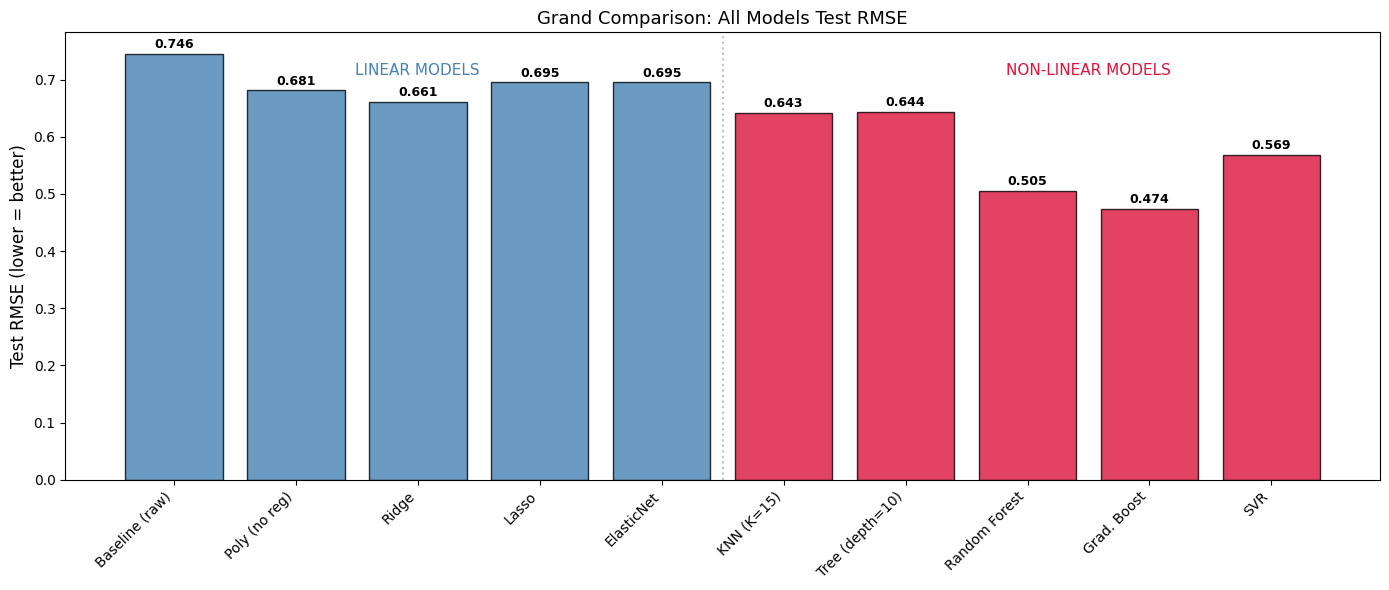


Overall Best Model: Grad. Boost (Test RMSE = 0.4737)
Best Linear Model: Ridge (Test RMSE = 0.6610)
Best Non-Linear Model: Grad. Boost (Test RMSE = 0.4737)


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Collect all results into lists
all_names = [
    'Baseline (raw)',
    'Poly (no reg)',
    'Ridge',
    'Lasso',
    'ElasticNet',
    f'KNN (K={best_k})',
    f'Tree (depth={best_tree_depth})',
    'Random Forest',
    'Grad. Boost',
    'SVR'
]

# Ensure all RMSE variables are defined from previous cells
# Baseline (raw features) from DUntGSQqNjZg
# Polynomial (no reg) from KER5Fb8nNjZh
# Best Ridge from DhsxSKmFNjZl
# Best Lasso from d_KVYtYXNjZn
# Best ElasticNet from -bl3yGVZNjZo
# Best KNN from lcN_8J9VNjZq or hgmb93eKNjZq
# Best Decision Tree from hgmb93eKNjZq
# Random Forest from hgmb93eKNjZq
# Gradient Boosting from hgmb93eKNjZq
# SVR from hgmb93eKNjZq

all_test_rmses = [
    rmse_test_baseline,
    rmse_test_poly,
    ridge_test_rmses[best_idx_ridge],
    lasso_test_rmses[best_idx_lasso],
    best_en_rmse,
    knn_results[best_k]['test'],
    tree_results[best_tree_depth]['test'],
    rf_rmse_te,
    gb_rmse_te,
    svr_rmse_te
]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue']*5 + ['crimson']*5  # blue for linear, red for non-linear
bars = ax.bar(all_names, all_test_rmses, color=colors, alpha=0.8, edgecolor='black')

# Add value labels on top of each bar
for bar, val in zip(bars, all_test_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')

# Add a vertical line separating linear from non-linear
ax.axvline(x=4.5, color='gray', linestyle=':', alpha=0.5)
ax.text(2.0, max(all_test_rmses)*0.95, 'LINEAR MODELS', ha='center', fontsize=11, color='steelblue')
ax.text(7.5, max(all_test_rmses)*0.95, 'NON-LINEAR MODELS', ha='center', fontsize=11, color='crimson')

ax.set_ylabel('Test RMSE (lower = better)', fontsize=12)
ax.set_title('Grand Comparison: All Models Test RMSE', fontsize=13)
plt.xticks(rotation=45, ha='right') # Rotate for better readability with long names
plt.tight_layout()
plt.show()

# Find the overall best model
best_model_idx = np.argmin(all_test_rmses)
best_model_name = all_names[best_model_idx]
best_model_rmse = all_test_rmses[best_model_idx]

print(f"\nOverall Best Model: {best_model_name} (Test RMSE = {best_model_rmse:.4f})")

# Find best linear model
linear_model_rmses = all_test_rmses[:5] # First 5 are linear models
best_linear_idx = np.argmin(linear_model_rmses)
best_linear_name = all_names[best_linear_idx]
best_linear_rmse = linear_model_rmses[best_linear_idx]
print(f"Best Linear Model: {best_linear_name} (Test RMSE = {best_linear_rmse:.4f})")

# Find best non-linear model
non_linear_model_rmses = all_test_rmses[5:] # Remaining are non-linear models
best_non_linear_idx = np.argmin(non_linear_model_rmses)
best_non_linear_name = all_names[5 + best_non_linear_idx]
best_non_linear_rmse = non_linear_model_rmses[best_non_linear_idx]
print(f"Best Non-Linear Model: {best_non_linear_name} (Test RMSE = {best_non_linear_rmse:.4f})")



---
## Quick Reference: Key sklearn APIs

| Class | Module | Key Parameters | Notes |
|-------|--------|----------------|-------|
| `LinearRegression` | `sklearn.linear_model` | `fit_intercept` | No regularization (OLS) |
| `Ridge` | `sklearn.linear_model` | `alpha` | L2 penalty only |
| `Lasso` | `sklearn.linear_model` | `alpha`, `max_iter` | L1 penalty, sparse |
| `ElasticNet` | `sklearn.linear_model` | `alpha`, `l1_ratio`, `max_iter` | Combined L1+L2 |
| `RidgeCV` | `sklearn.linear_model` | `alphas` | Auto-tunes alpha |
| `LassoCV` | `sklearn.linear_model` | `alphas`, `cv` | Auto-tunes alpha |
| `ElasticNetCV` | `sklearn.linear_model` | `alphas`, `l1_ratio`, `cv` | Auto-tunes both |
| `PolynomialFeatures` | `sklearn.preprocessing` | `degree`, `include_bias` | Feature expansion |
| `StandardScaler` | `sklearn.preprocessing` | — | Z-score normalization |
| `KFold` | `sklearn.model_selection` | `n_splits`, `shuffle` | CV splits |
| `mean_squared_error` | `sklearn.metrics` | `y_true`, `y_pred` | MSE metric |
| `r2_score` | `sklearn.metrics` | `y_true`, `y_pred` | R² metric |

**Documentation:** https://scikit-learn.org/stable/modules/linear_model.html